In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tabpfn_extensions.post_hoc_ensembles.sklearn_interface import AutoTabPFNRegressor
import matplotlib.pyplot as plt

# 读取数据
maccs_df = pd.read_excel('categorized_maccs.xlsx', sheet_name='Sheet1', header=0)
X = maccs_df.filter(regex='MACCS_\d+')
y = maccs_df['logkOH•']
stratify_column = maccs_df['chemical class-98']

# 移除常数列
constant_cols = X.columns[X.nunique() == 1]
X = X.drop(columns=constant_cols)

# 划分训练集和测试集（分层抽样）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    stratify=stratify_column,
    random_state=42
)

In [2]:
def create_missing_data(X, missing_rate):
    """生成指定缺失比例的数据"""
    mask = np.random.choice([True, False], size=X.shape, p=[missing_rate, 1-missing_rate])
    return pd.DataFrame(np.where(mask, np.nan, X), columns=X.columns)

# 实验参数
missing_rates = np.linspace(0.1, 0.5, 5)  # 生成[0.1, 0.2, 0.3, 0.4, 0.5]
n_repeats = 10
results = []

for rate in missing_rates:
    rate = round(rate, 2)  # 保持精度
    for _ in range(n_repeats):
        # 创建缺失数据集
        X_train_missing = create_missing_data(X_train, rate)
        X_test_missing = create_missing_data(X_test, rate)
        
        # 训练模型
        model = AutoTabPFNRegressor(
            device='cuda',
        ).fit(X_train_missing, y_train)
        
        # 预测并计算RMSE（直接使用sklearn的squared=False参数）
        y_pred = model.predict(X_test_missing)
        rmse = mean_squared_error(y_test, y_pred, squared=False)
        
        results.append({
            '缺失率': rate,
            'RMSE': rmse
        })

# 转换为DataFrame并分析
results_df = pd.DataFrame(results)
summary = results_df.groupby('缺失率').agg(['mean', 'std'])

2025-04-02 16:55:19 INFO     Using `default` preset for Post Hoc Ensemble.
2025-04-02 16:55:19 INFO     No categorical_feature_indices given. Assuming no categorical features.
2025-04-02 16:55:19 INFO     Using task type: regression
2025-04-02 16:55:19 INFO     Obtaining TabPFN models from a random portfolio.
2025-04-02 16:55:28 INFO     Using 100 base models: ['default_tabpfn_model_0', 'random_tabpfn_model_1', 'random_tabpfn_model_2', 'random_tabpfn_model_3', 'random_tabpfn_model_4', 'random_tabpfn_model_5', 'random_tabpfn_model_6', 'random_tabpfn_model_7', 'random_tabpfn_model_8', 'random_tabpfn_model_9', 'random_tabpfn_model_10', 'random_tabpfn_model_11', 'random_tabpfn_model_12', 'random_tabpfn_model_13', 'random_tabpfn_model_14', 'random_tabpfn_model_15', 'random_tabpfn_model_16', 'random_tabpfn_model_17', 'random_tabpfn_model_18', 'random_tabpfn_model_19', 'random_tabpfn_model_20', 'random_tabpfn_model_21', 'random_tabpfn_model_22', 'random_tabpfn_model_23', 'random_tabpfn_model_

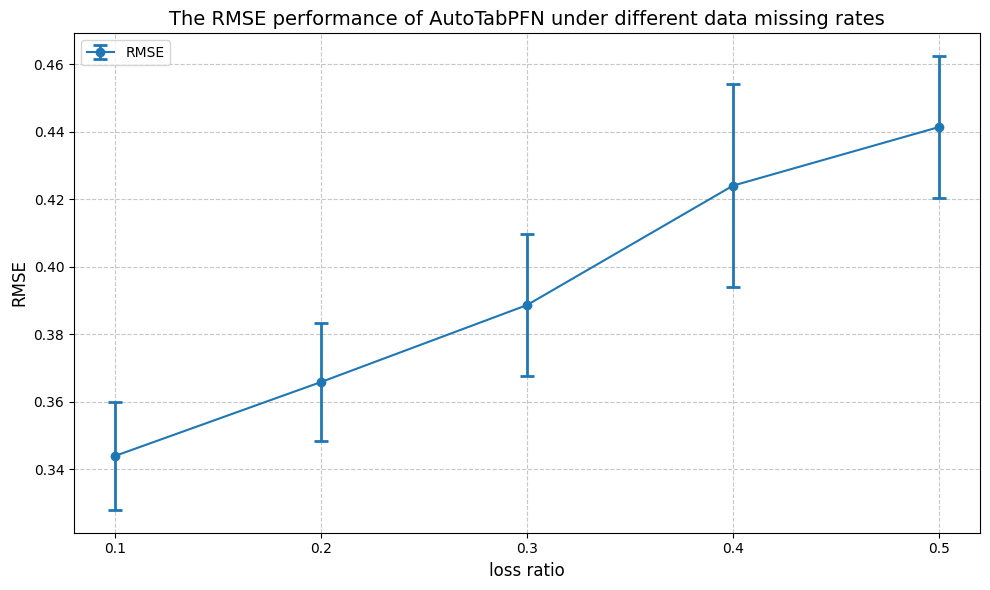

RMSE统计摘要：


In [3]:
# 可视化结果
plt.figure(figsize=(10, 6))
plt.errorbar(
    summary.index,
    summary['RMSE']['mean'],
    yerr=summary['RMSE']['std'],
    fmt='o-',
    capsize=5,
    capthick=2,
    elinewidth=2,
    label='RMSE'
)

plt.xlabel('loss ratio', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.title('The RMSE performance of AutoTabPFN under different data missing rates', fontsize=14)
plt.xticks(missing_rates)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# 输出统计结果
print("RMSE统计摘要：")
print(summary.style.format("{:.4f}"))

In [ ]:
results_df.to_csv('detailed_results_5.csv', index=False)  # CSV格式
results_df.to_excel('detailed_results_5.xlsx', index=False)  # Excel格式

# 保存汇总统计结果（注意处理多级列名）
summary.columns = ['_'.join(col).strip() for col in summary.columns.values]  # 展平多级列名
summary.reset_index(inplace=True)  # 将缺失率从索引转为列

summary.to_csv('missing_value_summary.csv', index=False)
summary.to_excel('missing_value_summary.xlsx', index=False)

In [8]:
# 实验参数
missing_rates = np.linspace(0, 0.5, 11)  # 生成[0.1, 0.2, 0.3, 0.4, 0.5]
n_repeats = 5
results = []

for rate in missing_rates:
    rate = round(rate, 2)  # 保持精度
    for _ in range(n_repeats):
        # 创建缺失数据集
        X_train_missing = create_missing_data(X_train, rate)
        X_test_missing = create_missing_data(X_test, rate)
        
        # 训练模型
        model = AutoTabPFNRegressor(
            device='cuda',
        ).fit(X_train_missing, y_train)
        
        # 预测并计算RMSE（直接使用sklearn的squared=False参数）
        y_pred = model.predict(X_test_missing)
        rmse = mean_squared_error(y_test, y_pred, squared=False)
        
        results.append({
            '缺失率': rate,
            'RMSE': rmse
        })

# 转换为DataFrame并分析
results_df = pd.DataFrame(results)
summary = results_df.groupby('缺失率').agg(['mean', 'std'])

2025-04-03 13:47:48 INFO     Using `default` preset for Post Hoc Ensemble.
2025-04-03 13:47:48 INFO     No categorical_feature_indices given. Assuming no categorical features.
2025-04-03 13:47:48 INFO     Using task type: regression
2025-04-03 13:47:48 INFO     Obtaining TabPFN models from a random portfolio.
2025-04-03 13:47:57 INFO     Using 100 base models: ['default_tabpfn_model_0', 'random_tabpfn_model_1', 'random_tabpfn_model_2', 'random_tabpfn_model_3', 'random_tabpfn_model_4', 'random_tabpfn_model_5', 'random_tabpfn_model_6', 'random_tabpfn_model_7', 'random_tabpfn_model_8', 'random_tabpfn_model_9', 'random_tabpfn_model_10', 'random_tabpfn_model_11', 'random_tabpfn_model_12', 'random_tabpfn_model_13', 'random_tabpfn_model_14', 'random_tabpfn_model_15', 'random_tabpfn_model_16', 'random_tabpfn_model_17', 'random_tabpfn_model_18', 'random_tabpfn_model_19', 'random_tabpfn_model_20', 'random_tabpfn_model_21', 'random_tabpfn_model_22', 'random_tabpfn_model_23', 'random_tabpfn_model_

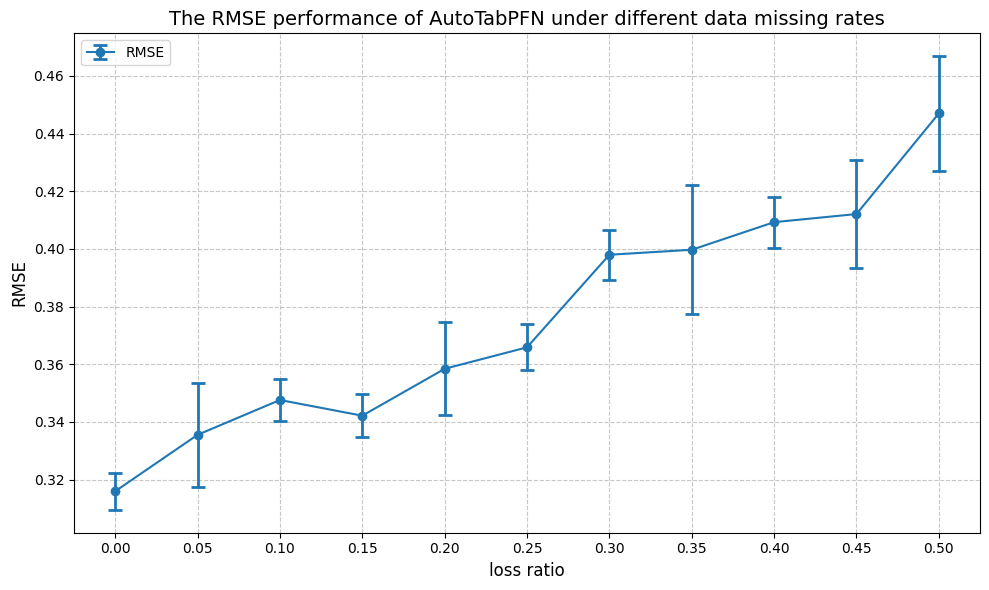

RMSE统计摘要：


In [10]:
# 可视化结果
plt.figure(figsize=(10, 6))
plt.errorbar(
    summary.index,
    summary['RMSE']['mean'],
    yerr=summary['RMSE']['std'],
    fmt='o-',
    capsize=5,
    capthick=2,
    elinewidth=2,
    label='RMSE'
)

plt.xlabel('loss ratio', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.title('The RMSE performance of AutoTabPFN under different data missing rates', fontsize=14)
plt.xticks(missing_rates)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# 输出统计结果
print("RMSE统计摘要：")
print(summary.style.format("{:.4f}"))

In [11]:
results_df.to_csv('detailed_results_11.csv', index=False)  # CSV格式
results_df.to_excel('detailed_results_11.xlsx', index=False)  # Excel格式

# 保存汇总统计结果（注意处理多级列名）
summary.columns = ['_'.join(col).strip() for col in summary.columns.values]  # 展平多级列名
summary.reset_index(inplace=True)  # 将缺失率从索引转为列

summary.to_csv('missing_value_summary_11points.csv', index=False)
summary.to_excel('missing_value_summary_11points.xlsx', index=False)